# <h1 align="center"> Machine Learnign Template </h1> </center>

<p style="margin-bottom:1cm;"></p>

# One hot encoding at the start

## 1. Load Dependencies

In [1]:
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.metrics import confusion_matrix, classification_report, f1_score

import matplotlib.pyplot as plt
import seaborn as sns


## 2. Loading Dataset


In [2]:
df = pd.read_csv("telecom_users.csv").drop(columns="Unnamed: 0")
print(df.shape)
df.head()

(5986, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7010-BRBUU,Male,0,Yes,Yes,72,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Credit card (automatic),24.10,1734.65,No
1,9688-YGXVR,Female,0,No,No,44,Yes,No,Fiber optic,No,...,Yes,No,Yes,No,Month-to-month,Yes,Credit card (automatic),88.15,3973.2,No
2,9286-DOJGF,Female,1,Yes,No,38,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Bank transfer (automatic),74.95,2869.85,Yes
3,6994-KERXL,Male,0,No,No,4,Yes,No,DSL,No,...,No,No,No,Yes,Month-to-month,Yes,Electronic check,55.90,238.5,No
4,2181-UAESM,Male,0,No,No,2,Yes,No,DSL,Yes,...,Yes,No,No,No,Month-to-month,No,Electronic check,53.45,119.5,No


Churn = yes - they leave the company - e.g. bad
Churn = no - they stay - e.g. good

## 3. Data Preparation and check (shape, info for the column types, checking for missing values)

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5986 entries, 0 to 5985
Data columns (total 22 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Unnamed: 0        5986 non-null   int64  
 1   customerID        5986 non-null   str    
 2   gender            5986 non-null   str    
 3   SeniorCitizen     5986 non-null   int64  
 4   Partner           5986 non-null   str    
 5   Dependents        5986 non-null   str    
 6   tenure            5986 non-null   int64  
 7   PhoneService      5986 non-null   str    
 8   MultipleLines     5986 non-null   str    
 9   InternetService   5986 non-null   str    
 10  OnlineSecurity    5986 non-null   str    
 11  OnlineBackup      5986 non-null   str    
 12  DeviceProtection  5986 non-null   str    
 13  TechSupport       5986 non-null   str    
 14  StreamingTV       5986 non-null   str    
 15  StreamingMovies   5986 non-null   str    
 16  Contract          5986 non-null   str    
 17  Paperl

In [8]:
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors='coerce')
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5986 entries, 0 to 5985
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        5986 non-null   str    
 1   gender            5986 non-null   str    
 2   SeniorCitizen     5986 non-null   int64  
 3   Partner           5986 non-null   str    
 4   Dependents        5986 non-null   str    
 5   tenure            5986 non-null   int64  
 6   PhoneService      5986 non-null   str    
 7   MultipleLines     5986 non-null   str    
 8   InternetService   5986 non-null   str    
 9   OnlineSecurity    5986 non-null   str    
 10  OnlineBackup      5986 non-null   str    
 11  DeviceProtection  5986 non-null   str    
 12  TechSupport       5986 non-null   str    
 13  StreamingTV       5986 non-null   str    
 14  StreamingMovies   5986 non-null   str    
 15  Contract          5986 non-null   str    
 16  PaperlessBilling  5986 non-null   str    
 17  Paymen

In [9]:
df.isna().sum() #same as isnull, but this is the newer and preferred format. 

customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        10
Churn                0
dtype: int64

In [14]:
df[df["TotalCharges"].isna()]


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
356,2775-SEFEE,Male,0,No,Yes,0,Yes,Yes,DSL,Yes,...,No,Yes,No,No,Two year,Yes,Bank transfer (automatic),61.90,NaN,No
634,1371-DWPAZ,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,NaN,No
2771,3213-VVOLG,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,NaN,No
3086,2923-ARZLG,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,NaN,No
3255,7644-OMVMY,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.85,NaN,No
4326,5709-LVOEQ,Female,0,Yes,Yes,0,Yes,No,DSL,Yes,...,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,NaN,No
5375,3115-CZMZD,Male,0,No,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,NaN,No
5382,2520-SGTTA,Female,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,NaN,No
5695,4472-LVYGI,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,NaN,No
5951,4367-NUYAO,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,NaN,No


### Filtering for duplicates
We also need to figure out with the duplicates. We can keep the last one of the copies, or only keep the duplicates and drop the rest. 
It is also not necessary to pick a column to check, so then it compares all the rows.

After filtering we might need to reset the rows with .reset_index(drop=True)

In [15]:
df = df.drop_duplicates(keep="last")
len(df)

5986

In [3]:
for col in df.columns:
    print(f"\n{col}:")
    print(df[col].value_counts(dropna=False))


customerID:
customerID
7010-BRBUU    1
9688-YGXVR    1
9286-DOJGF    1
6994-KERXL    1
2181-UAESM    1
             ..
0684-AOSIH    1
5982-PSMKW    1
8044-BGWPI    1
7450-NWRTR    1
4795-UXVCJ    1
Name: count, Length: 5986, dtype: int64

gender:
gender
Male      3050
Female    2936
Name: count, dtype: int64

SeniorCitizen:
SeniorCitizen
0    5020
1     966
Name: count, dtype: int64

Partner:
Partner
No     3082
Yes    2904
Name: count, dtype: int64

Dependents:
Dependents
No     4195
Yes    1791
Name: count, dtype: int64

tenure:
tenure
1     510
72    308
2     194
3     169
4     154
     ... 
44     47
45     47
39     44
36     43
0      10
Name: count, Length: 73, dtype: int64

PhoneService:
PhoneService
Yes    5396
No      590
Name: count, dtype: int64

MultipleLines:
MultipleLines
No                  2848
Yes                 2548
No phone service     590
Name: count, dtype: int64

InternetService:
InternetService
Fiber optic    2627
DSL            2068
No             1291
Nam

In [4]:
for col in df.columns:
    print(f"\n{col}:")
    print(df[col].nunique(dropna=False))


customerID:
5986

gender:
2

SeniorCitizen:
2

Partner:
2

Dependents:
2

tenure:
73

PhoneService:
2

MultipleLines:
3

InternetService:
3

OnlineSecurity:
3

OnlineBackup:
3

DeviceProtection:
3

TechSupport:
3

StreamingTV:
3

StreamingMovies:
3

Contract:
3

PaperlessBilling:
2

PaymentMethod:
4

MonthlyCharges:
1526

TotalCharges:
5611

Churn:
2


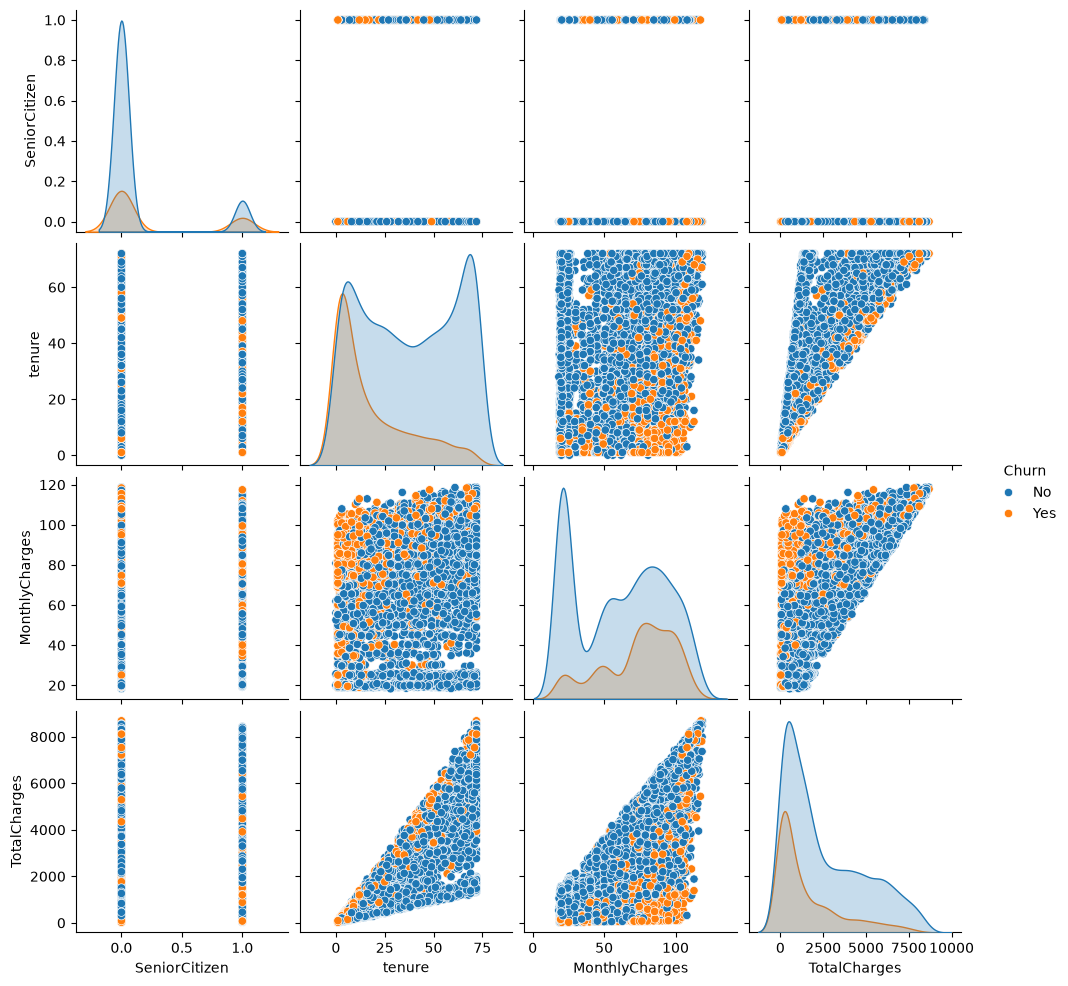

In [19]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.pairplot(df, hue="Churn")
plt.show()

In [35]:
df2 = df.drop(columns="customerID").copy()
df2.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Male,0,Yes,Yes,72,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Credit card (automatic),24.10,1734.65,No
1,Female,0,No,No,44,Yes,No,Fiber optic,No,Yes,Yes,No,Yes,No,Month-to-month,Yes,Credit card (automatic),88.15,3973.20,No
2,Female,1,Yes,No,38,Yes,Yes,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Bank transfer (automatic),74.95,2869.85,Yes
3,Male,0,No,No,4,Yes,No,DSL,No,No,No,No,No,Yes,Month-to-month,Yes,Electronic check,55.90,238.50,No
4,Male,0,No,No,2,Yes,No,DSL,Yes,No,Yes,No,No,No,Month-to-month,No,Electronic check,53.45,119.50,No


In [36]:
cat_features = df2.select_dtypes(include=['object', 'category', 'string']).columns.tolist()
numc_features = df2.select_dtypes(include=['int', 'float']).columns.tolist()


In [44]:
key = {c: df2[c].astype("category").cat.categories[0] for c in cat_features}

df_encoded = pd.get_dummies(df2, columns=cat_features, drop_first=True, dtype=int, prefix_sep="__")



In [46]:
df_encoded.head()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,gender__Male,Partner__Yes,Dependents__Yes,PhoneService__Yes,MultipleLines__No phone service,MultipleLines__Yes,...,StreamingTV__Yes,StreamingMovies__No internet service,StreamingMovies__Yes,Contract__One year,Contract__Two year,PaperlessBilling__Yes,PaymentMethod__Credit card (automatic),PaymentMethod__Electronic check,PaymentMethod__Mailed check,Churn__Yes
0,0,72,24.10,1734.65,1,1,1,1,0,1,...,0,1,0,0,1,0,1,0,0,0
1,0,44,88.15,3973.20,0,0,0,1,0,0,...,1,0,0,0,0,1,1,0,0,0
2,1,38,74.95,2869.85,0,1,0,1,0,1,...,0,0,0,0,0,1,0,0,0,1
3,0,4,55.90,238.50,1,0,0,1,0,0,...,0,0,1,0,0,1,0,1,0,0
4,0,2,53.45,119.50,1,0,0,1,0,0,...,0,0,0,0,0,0,0,1,0,0


In [49]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.pairplot(df_encoded, hue="Churn__Yes")
plt.show()

KeyboardInterrupt: 

Error in callback <function flush_figures at 0x000001BE4CB04D60> (for post_execute), with arguments args (),kwargs {}:


KeyboardInterrupt: 

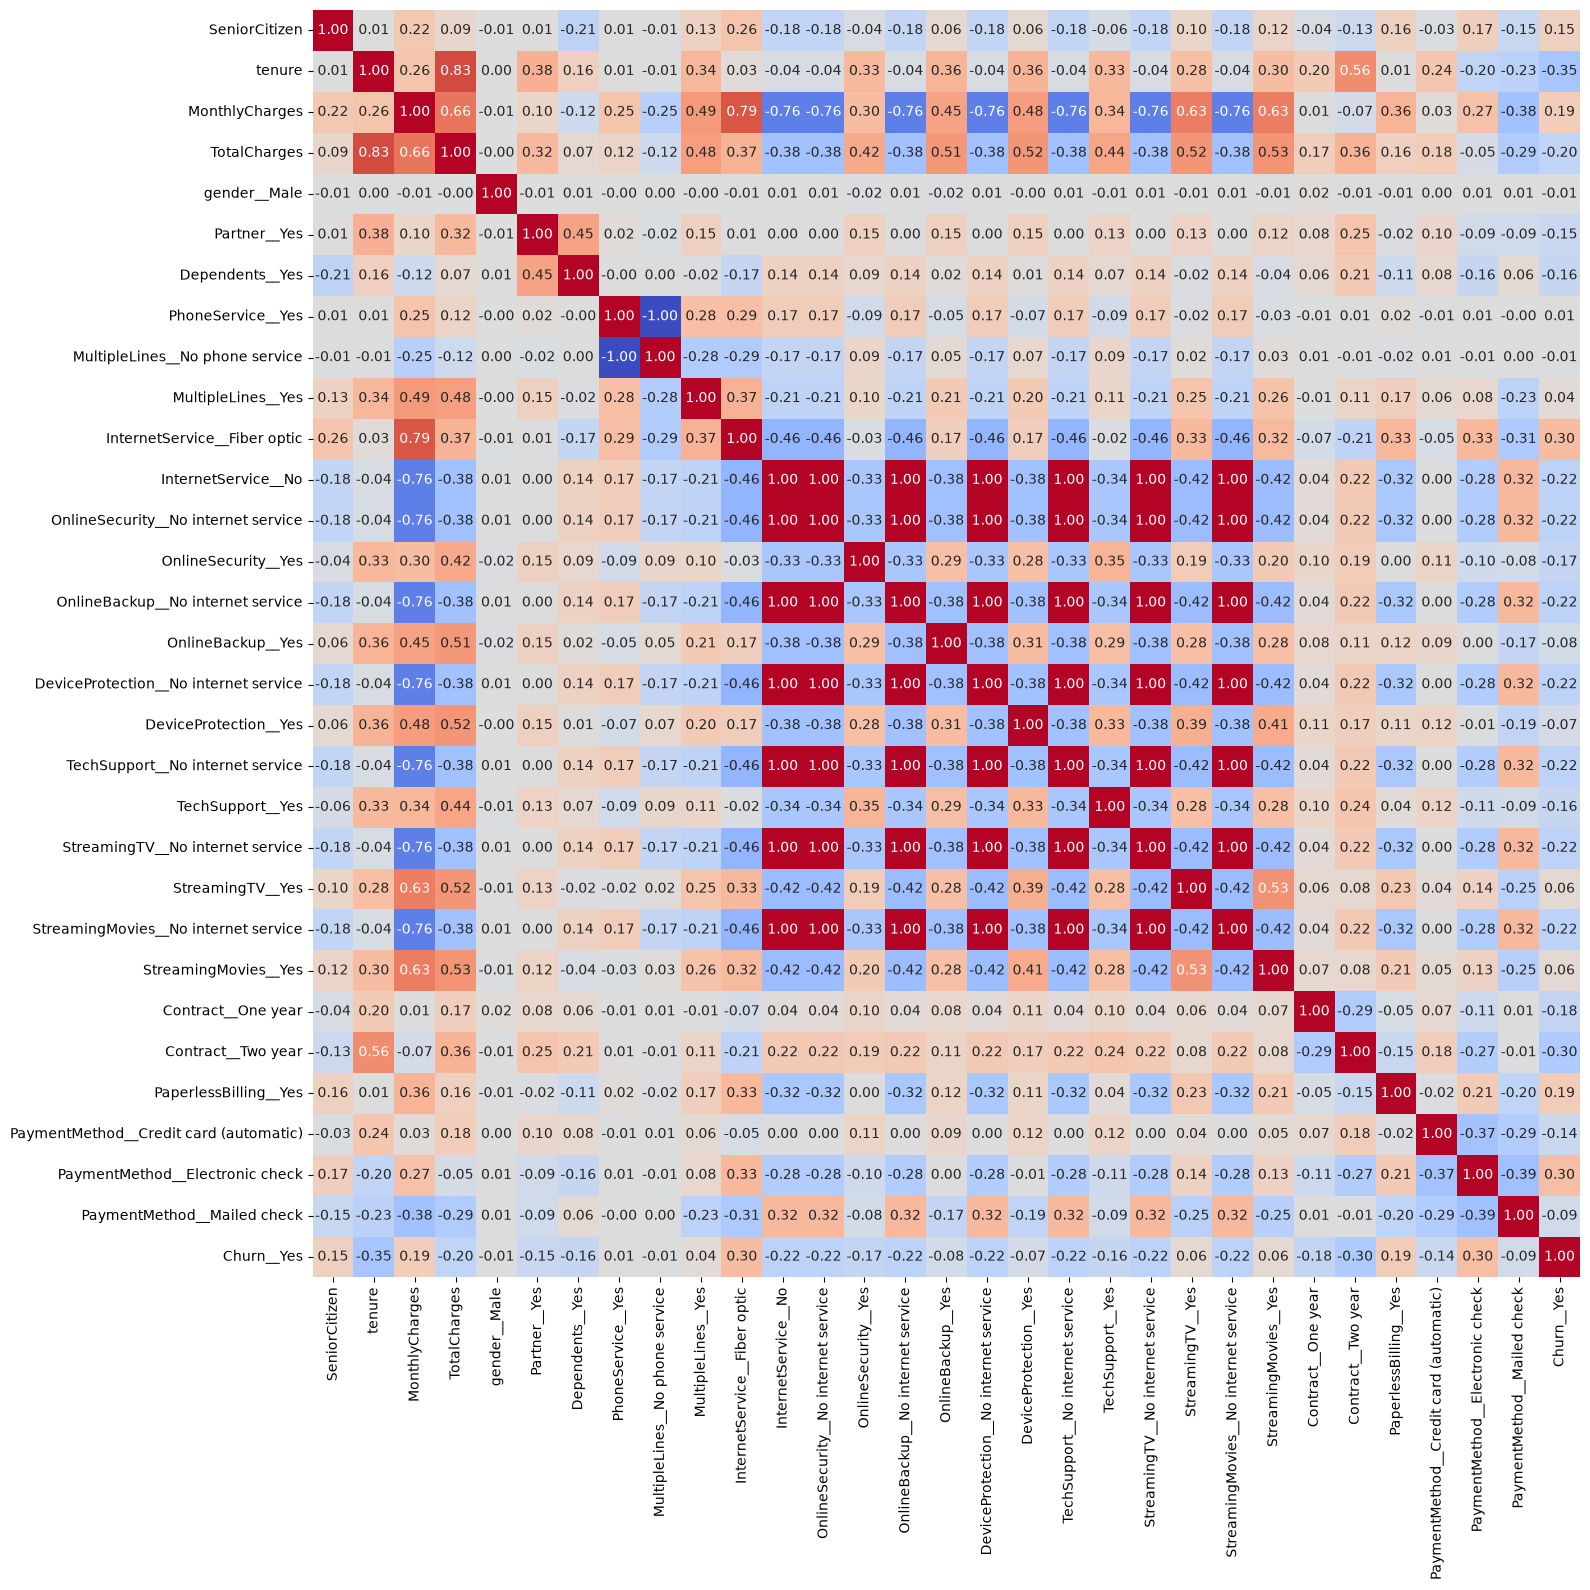

In [54]:
plt.figure(figsize=(20, 16))
sns.heatmap(df_encoded.corr(method="pearson"), cmap="coolwarm", vmin=-1, vmax=1,
                annot=True, fmt=".2f", square=True, cbar=False)
plt.tight_layout()
plt.show()
 

# This is the reverse of the encoding

In [ ]:

dummy_cols = [c for c in df_encoded.columns if "__" in c]
back = pd.from_dummies(df_encoded[dummy_cols], sep="__", default_category=key)
df_back = pd.concat([df_encoded.drop(columns=dummy_cols), back], axis=1)

## 4. Splitting the data
With limited amount of data (<1000) it is usually better to do the split with smaller split size (10%).

In [17]:
X = df.drop(columns=['Churn',"customerID" ])
y = df['Churn']


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y) #Stratify makes sure that the split of the data will have the same proportion of the "y" variable as the original dataset. Basically the next line of code for the proportion checking becomes unnecessary. "y" referes to the column and not to "yes"!!
X_train.shape, X_test.shape

((4788, 19), (1198, 19))

# 5. Training 



## Separate categorical and numeric columns

We will need to treat these features separately just like before

In [24]:
categorical_features = X_train.select_dtypes(include=['object', 'category', 'string']).columns.tolist()
numeric_features = X_train.select_dtypes(include=['int', 'float']).columns.tolist()


## Define Categorical and Numerical Transformer Pipeline

Tranformation of the categorical features:

- Constant imputer (SimpleImputer) to fill missing values
- One-hot encoder to get dummy variables

Tranformation of the categorical features:

- Standard Scaler to scale the numeric features
- K-nearest neighbor imputer to fill missing values

Processor: tranform all the features in sequence

- Numeric Transfomer defined earlier
- Categorical Transfomer defined earlier

In [26]:
categorical_transformer = Pipeline(steps=[
                                          ("cat_imputer", SimpleImputer(strategy='constant',
                                                                        fill_value='Not Available').set_output(transform="pandas")),
                                          ("onehot", OneHotEncoder(sparse_output=False,
                                                                   handle_unknown="ignore").set_output(transform="pandas"))
                                          ])

numeric_transformer = Pipeline(steps=[
                                      ("scaler", StandardScaler().set_output(transform="pandas")),
                                      ("knn_imputer", KNNImputer(n_neighbors=5).set_output(transform="pandas")) #This is in here to fill in NaN-s because some model would crush on missing vales. 
                                      ])

preprocessor = ColumnTransformer(transformers=[
                                               ("num", numeric_transformer,
                                                       numeric_features),
                                               ("cat", categorical_transformer,
                                                       categorical_features)
                                               ]).set_output(transform="pandas")

## Logistic Regression Modeling Pipeline

Chains the following steps:

- Preprocessing pipeline steps defined earlier (categorical to numerical encoding, scaling, filling NaNs)
- Logistic Regression model 

## Train and Evaluate Logistic Regression ML Pipeline



In [27]:
from sklearn.linear_model import LogisticRegression

pipeline_lr = Pipeline(steps=[
                              ("pre_process", preprocessor),
                              ("model", LogisticRegression(random_state=42, solver='liblinear'))
                              ])


pipeline_lr.fit(X_train, y_train)
y_pred = pipeline_lr.predict(X_test)

class_labels = pipeline_lr.named_steps['model'].classes_ #I do not know what is the purpose of these class lables. 

print(classification_report(y_test, y_pred))

pd.DataFrame(confusion_matrix(y_test, y_pred),
             columns=class_labels, index=class_labels)


              precision    recall  f1-score   support

          No       0.85      0.91      0.88       704
         Yes       0.68      0.56      0.61       254

    accuracy                           0.81       958
   macro avg       0.77      0.73      0.74       958
weighted avg       0.80      0.81      0.81       958



,No,Yes
No,638,66
Yes,113,141


In [29]:
scores = {}
scores['log_reg'] = round(f1_score(y_test, y_pred, average='weighted'), 3)
scores

{'log_reg': 0.807}

## Train and Evaluate K Nearest Neighbors (KNN) ML Pipeline


### This first part is for finding the best neighbour in the current split.

In [ ]:
# from sklearn.neighbors import KNeighborsClassifier
# from sklearn.model_selection import cross_val_score

# best_neighbour = {}
# for n in range(1, 51, 2):
#     pipeline_knn = Pipeline([("pre_process", preprocessor),
#                             ("scaler", StandardScaler().set_output(transform="pandas")),
#                             ("model", KNeighborsClassifier(n_neighbors=n))])
#     pipeline_knn.fit(X_train, y_train)
#     y_pred = pipeline_knn.predict(X_test)

#     best_neighbour[n] = cross_val_score(pipeline_knn, X_train, y_train, cv=3, scoring="f1_macro").mean()
    
# df_neighbour = pd.DataFrame(list(best_neighbour.items()), columns=["n_neighbours", "f1_score"])


In [ ]:
# import plotly.express as px 
# fig = px.line(x=df_neighbour["n_neighbours"], y=df_neighbour["f1_score"], title="F1 score in the light of number of neighbours")
# fig.show()

## Using the best neighbour number in the actual model pipeline

In [35]:
pipeline_knn = Pipeline([("pre_process", preprocessor),
                            ("model", KNeighborsClassifier(n_neighbors=11))])

pipeline_knn.fit(X_train, y_train)
y_pred = pipeline_knn.predict(X_test)

class_labels = pipeline_knn.named_steps['model'].classes_

print(classification_report(y_test, y_pred))

pd.DataFrame(confusion_matrix(y_test, y_pred),
             columns=class_labels, index=class_labels)

              precision    recall  f1-score   support

          No       0.85      0.87      0.86       704
         Yes       0.61      0.57      0.59       254

    accuracy                           0.79       958
   macro avg       0.73      0.72      0.73       958
weighted avg       0.79      0.79      0.79       958



,No,Yes
No,612,92
Yes,108,146


In [36]:
scores['knn'] = round(f1_score(y_test, y_pred, average='weighted'), 3)
scores

{'log_reg': 0.807, 'knn': 0.789}

## Train and Evaluate SVM ML Pipeline


In [37]:
from sklearn.svm import LinearSVC
pipeline_svc = Pipeline([("pre_process", preprocessor),
                         ("model", LinearSVC(random_state=42, max_iter=10000))])


pipeline_svc.fit(X_train, y_train)
y_pred = pipeline_svc.predict(X_test)

class_labels = pipeline_svc.named_steps['model'].classes_

print(classification_report(y_test, y_pred))

pd.DataFrame(confusion_matrix(y_test, y_pred),
             columns=class_labels, index=class_labels)

              precision    recall  f1-score   support

          No       0.85      0.91      0.88       704
         Yes       0.69      0.56      0.62       254

    accuracy                           0.82       958
   macro avg       0.77      0.73      0.75       958
weighted avg       0.81      0.82      0.81       958



,No,Yes
No,641,63
Yes,112,142


In [38]:
scores['svm'] = round(f1_score(y_test, y_pred, average='weighted'), 3)
scores

{'log_reg': 0.807, 'knn': 0.789, 'svm': 0.811}

## Train and Evaluate Naive Bayes ML Pipeline
This model does not need scaling.
MultinomialNB / ComplementNB would crash after standardization, given the negative values.

Which distribution to use:
- BernoulliNB assumes binary (0/1) features. By default it binarises every feature at binarize=0.0, so with continuous, all-positive data nearly everything becomes 1 and the model loses most of the information.
- GaussianNB is the one for continuous numeric features. 
- MultinomialNB is for counts, like word frequencies.

In [39]:
categorical_transformer = Pipeline(steps=[
                                          ("cat_imputer", SimpleImputer(strategy='constant',
                                                                        fill_value='Not Available').set_output(transform="pandas")),
                                          ("onehot", OneHotEncoder(sparse_output=False,
                                                                   handle_unknown="ignore").set_output(transform="pandas"))
                                          ])

numeric_transformer = Pipeline(steps=[
                                      ("knn_imputer", KNNImputer(n_neighbors=5).set_output(transform="pandas")) # no standard scaling for numeric data
                                      ]) #see there is no scaler here

preprocessor_new = ColumnTransformer(transformers=[
                                               ("num", numeric_transformer,
                                                       numeric_features),
                                               ("cat", categorical_transformer,
                                                       categorical_features)
                                               ]).set_output(transform="pandas")

In [40]:
from sklearn.naive_bayes import BernoulliNB

pipeline_nb = Pipeline([("pre_process", preprocessor_new),
                         ("model", BernoulliNB())
                         ])

pipeline_nb.fit(X_train, y_train)
y_pred = pipeline_nb.predict(X_test)

class_labels = pipeline_nb.named_steps['model'].classes_

print(classification_report(y_test, y_pred))

pd.DataFrame(confusion_matrix(y_test, y_pred),
             columns=class_labels, index=class_labels)

              precision    recall  f1-score   support

          No       0.89      0.80      0.84       704
         Yes       0.56      0.72      0.63       254

    accuracy                           0.78       958
   macro avg       0.72      0.76      0.73       958
weighted avg       0.80      0.78      0.78       958



,No,Yes
No,560,144
Yes,71,183


In [41]:
scores['nb'] = round(f1_score(y_test, y_pred, average='weighted'), 3)
scores

{'log_reg': 0.807, 'knn': 0.789, 'svm': 0.811, 'nb': 0.784}

## Tree-based models don't require data to be scaled - hence the new processer is used down the line.

Tree based models are non-linear and are not distance based models. Hence we will create a new transformation pipeline without scaling

## Train and Evaluate Decision Tree ML Pipeline


In [42]:
from sklearn.tree import DecisionTreeClassifier
pipeline_dtree = Pipeline([("pre_process", preprocessor_new),
                         ("model", DecisionTreeClassifier(random_state=42))])


pipeline_dtree.fit(X_train, y_train)
y_pred = pipeline_dtree.predict(X_test)

class_labels = pipeline_dtree.named_steps['model'].classes_

print(classification_report(y_test, y_pred))

pd.DataFrame(confusion_matrix(y_test, y_pred),
             columns=class_labels, index=class_labels)

              precision    recall  f1-score   support

          No       0.82      0.87      0.84       704
         Yes       0.57      0.49      0.52       254

    accuracy                           0.77       958
   macro avg       0.70      0.68      0.68       958
weighted avg       0.76      0.77      0.76       958



,No,Yes
No,609,95
Yes,130,124


In [43]:
scores['dtree'] = round(f1_score(y_test, y_pred, average='weighted'), 3)
scores

{'log_reg': 0.807, 'knn': 0.789, 'svm': 0.811, 'nb': 0.784, 'dtree': 0.759}

## Train and Evaluate Random Forest ML Pipeline


In [44]:
from sklearn.ensemble import RandomForestClassifier
pipeline_rf = Pipeline([("pre_process", preprocessor_new),
                         ("model", RandomForestClassifier(random_state=42))])

pipeline_rf.fit(X_train, y_train)
y_pred = pipeline_rf.predict(X_test)

class_labels = pipeline_rf.named_steps['model'].classes_

print(classification_report(y_test, y_pred))

pd.DataFrame(confusion_matrix(y_test, y_pred),
             columns=class_labels, index=class_labels)

              precision    recall  f1-score   support

          No       0.82      0.91      0.86       704
         Yes       0.65      0.45      0.53       254

    accuracy                           0.79       958
   macro avg       0.74      0.68      0.70       958
weighted avg       0.78      0.79      0.78       958



,No,Yes
No,642,62
Yes,139,115


In [45]:
scores['rf'] = round(f1_score(y_test, y_pred, average='weighted'), 3)
scores

{'log_reg': 0.807,
 'knn': 0.789,
 'svm': 0.811,
 'nb': 0.784,
 'dtree': 0.759,
 'rf': 0.777}

## Train and Evaluate AdaBoost ML Pipeline


In [46]:
from sklearn.ensemble import AdaBoostClassifier

pipeline_ada_boost = Pipeline([("pre_process", preprocessor_new),
                         ("model", AdaBoostClassifier(random_state=42))])


pipeline_ada_boost.fit(X_train, y_train)
y_pred = pipeline_ada_boost.predict(X_test)

class_labels = pipeline_ada_boost.named_steps['model'].classes_

print(classification_report(y_test, y_pred))

pd.DataFrame(confusion_matrix(y_test, y_pred),
             columns=class_labels, index=class_labels)

              precision    recall  f1-score   support

          No       0.84      0.89      0.86       704
         Yes       0.63      0.54      0.58       254

    accuracy                           0.80       958
   macro avg       0.74      0.71      0.72       958
weighted avg       0.79      0.80      0.79       958



,No,Yes
No,625,79
Yes,117,137


In [47]:
scores['ada_boost'] = round(f1_score(y_test, y_pred, average='weighted'), 3)
scores

{'log_reg': 0.807,
 'knn': 0.789,
 'svm': 0.811,
 'nb': 0.784,
 'dtree': 0.759,
 'rf': 0.777,
 'ada_boost': 0.79}

## Train and Evaluate Gradient Boosting ML Pipeline


In [48]:
from sklearn.ensemble import GradientBoostingClassifier

pipeline_gbm = Pipeline([("pre_process", preprocessor_new),
                         ("model", GradientBoostingClassifier(random_state=42))])


pipeline_gbm.fit(X_train, y_train)
y_pred = pipeline_gbm.predict(X_test)

class_labels = pipeline_gbm.named_steps['model'].classes_

print(classification_report(y_test, y_pred))

pd.DataFrame(confusion_matrix(y_test, y_pred),
             columns=class_labels, index=class_labels)

              precision    recall  f1-score   support

          No       0.83      0.91      0.87       704
         Yes       0.67      0.50      0.57       254

    accuracy                           0.80       958
   macro avg       0.75      0.71      0.72       958
weighted avg       0.79      0.80      0.79       958



,No,Yes
No,642,62
Yes,127,127


In [49]:
scores['gbm'] = round(f1_score(y_test, y_pred, average='weighted'), 3)
scores

{'log_reg': 0.807,
 'knn': 0.789,
 'svm': 0.811,
 'nb': 0.784,
 'dtree': 0.759,
 'rf': 0.777,
 'ada_boost': 0.79,
 'gbm': 0.793}

## Train and Evaluate Extreme Gradient Boosting (XGBoost) ML Pipeline


In [53]:
from xgboost import XGBClassifier
pipeline_xgb = Pipeline([("pre_process", preprocessor_new),
                         ("model", XGBClassifier(random_state=42))])



In [54]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
# transform y labels into 0 and 1 as latest xgboost version doesn't support string labels
y_train_le = le.fit_transform(y_train)
y_test_le = le.transform(y_test)

In [55]:
pipeline_xgb.fit(X_train, y_train_le)
y_pred_le = pipeline_xgb.predict(X_test)

In [56]:
y_pred = le.inverse_transform(y_pred_le)

In [57]:
class_labels = le.classes_

print(classification_report(y_test, y_pred))

pd.DataFrame(confusion_matrix(y_test, y_pred),
             columns=class_labels, index=class_labels)

              precision    recall  f1-score   support

          No       0.83      0.90      0.86       704
         Yes       0.64      0.48      0.55       254

    accuracy                           0.79       958
   macro avg       0.73      0.69      0.71       958
weighted avg       0.78      0.79      0.78       958



,No,Yes
No,634,70
Yes,131,123


In [58]:
scores['xgb'] = round(f1_score(y_test, y_pred, average='weighted'), 3)
scores

{'log_reg': 0.807,
 'knn': 0.789,
 'svm': 0.811,
 'nb': 0.784,
 'dtree': 0.759,
 'rf': 0.777,
 'ada_boost': 0.79,
 'gbm': 0.793,
 'xgb': 0.78}

## Compare model performances

In [59]:
result = pd.DataFrame({
    "Model" : scores.keys(),
    'F1-Score': scores.values()
})

result

,Model,F1-Score
0,log_reg,0.807
1,knn,0.789
2,svm,0.811
3,nb,0.784
4,dtree,0.759
5,rf,0.777
6,ada_boost,0.790
7,gbm,0.793
8,xgb,0.780


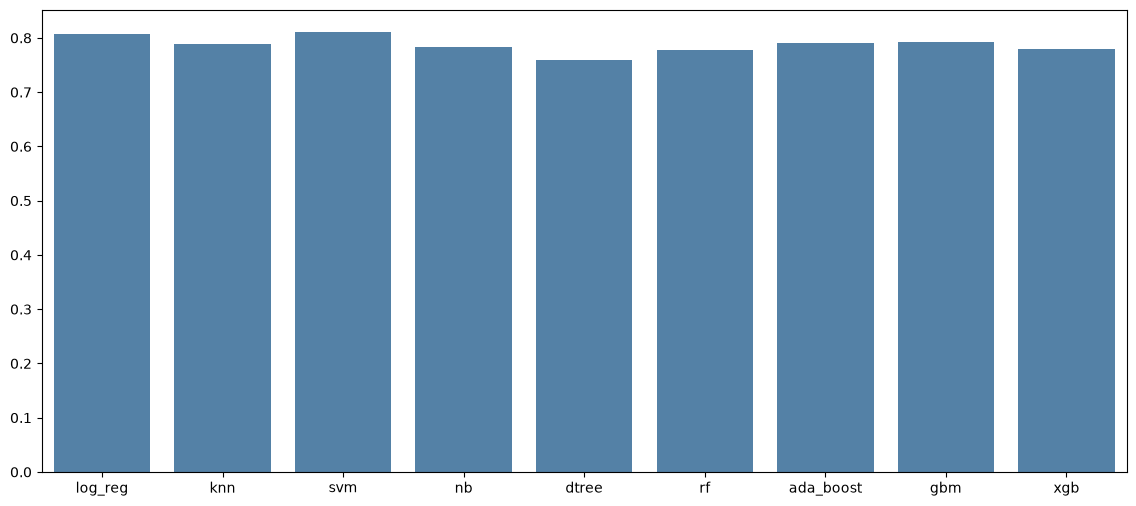

In [60]:
plt.figure(figsize=(14, 6))
sns.barplot(x=list(scores.keys()),
            y=list(scores.values()), color="Steelblue");

## Feature Importance

Trees based models like RandomForest, XGBoost, etc.  provide us feature importance based on the training.

In [61]:
xgb_model = pipeline_xgb['model']
feature_names = pipeline_xgb['pre_process'].get_feature_names_out()
feature_names

array(['num__SeniorCitizen', 'num__tenure', 'num__MonthlyCharges', ...,
       'cat__TotalCharges_999.45', 'cat__TotalCharges_999.8',
       'cat__TotalCharges_999.9'], shape=(3702,), dtype=object)

In [62]:
xgb_model.feature_importances_

array([0.0118527 , 0.01403137, 0.01045763, ..., 0.        , 0.        ,
       0.        ], shape=(3702,), dtype=float32)

In [63]:
xgb_importances = pd.DataFrame(
    {"feature": feature_names, "importance": np.round(xgb_model.feature_importances_, 3)}
)
xgb_importances = xgb_importances.sort_values("importance", ascending=False).set_index(
    "feature"
)
xgb_importances.head(20)

,importance
feature,
cat__Contract_Month-to-month,0.368
cat__InternetService_Fiber optic,0.260
cat__PhoneService_No,0.023
cat__OnlineSecurity_No,0.023
cat__Contract_Two year,0.021
cat__StreamingMovies_Yes,0.020
cat__Contract_One year,0.016
cat__OnlineBackup_No,0.016
cat__TechSupport_No,0.014


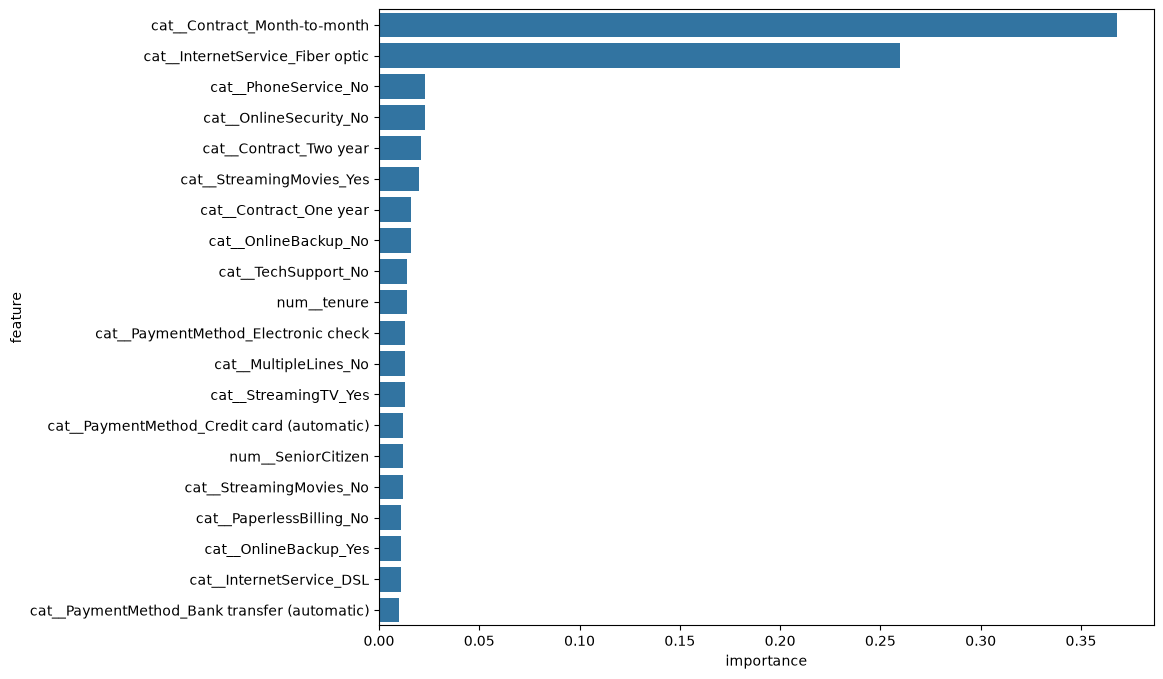

In [64]:
plt.figure(figsize=(10, 8))
sns.barplot(y=xgb_importances.head(20).index,
            x=xgb_importances.head(20).importance);

## Cross-Validation Evaluation and Model Comparison (Optional)

Standard process followed in the industry to compare multiple ML models

In [65]:
from sklearn.model_selection import cross_val_score

#### Cross-Validating based on Average F1 score

In [ ]:
cvs = 3
scores_cv = {}
scores_cv['log_reg'] = cross_val_score(pipeline_lr, X_train, y_train, cv=cvs, scoring='f1_weighted')
scores_cv['knn'] = cross_val_score(pipeline_knn, X_train, y_train, cv=cvs, scoring='f1_weighted')
scores_cv['nb'] = cross_val_score(pipeline_nb, X_train, y_train, cv=cvs, scoring='f1_weighted')
scores_cv['svm'] = cross_val_score(pipeline_svc, X_train, y_train, cv=cvs, scoring='f1_weighted')
scores_cv['dtree'] = cross_val_score(pipeline_dtree, X_train, y_train, cv=cvs, scoring='f1_weighted')
scores_cv['rf'] = cross_val_score(pipeline_rf, X_train, y_train, cv=cvs, scoring='f1_weighted')
scores_cv['ada_boost'] = cross_val_score(pipeline_ada_boost, X_train, y_train, cv=cvs, scoring='f1_weighted')
scores_cv['gbm'] = cross_val_score(pipeline_gbm, X_train, y_train, cv=cvs, scoring='f1_weighted')
# here labels need to be used as 0 and 1 which are label encoded
scores_cv['xgb'] = cross_val_score(pipeline_xgb, X_train, y_train_le, cv=cvs, scoring='f1_weighted')

In [67]:
result = pd.DataFrame({
    "Model" : scores_cv.keys(),
    'F1-Score': [round(np.mean(scores), 3) for scores in scores_cv.values()]
})

result.sort_values("F1-Score", ascending=False)

,Model,F1-Score
7,gbm,0.798
0,log_reg,0.794
6,ada_boost,0.794
3,svm,0.792
1,knn,0.775
8,xgb,0.775
4,dtree,0.772
5,rf,0.769
2,nb,0.767


In [71]:
y_train2 = y_train.copy()

In [73]:
y_train2

499     Yes
381      No
3891    Yes
874      No
2249    Yes
       ... 
1609     No
1866    Yes
1106    Yes
5050     No
5248     No
Name: Churn, Length: 3830, dtype: str

In [ ]:
from flaml import AutoML

automl = AutoML()

automl_settings = {
    "time_budget": 30, # 10 mins to try and select the best model
    "metric": 'macro_f1', #if it is only f1, then it expect a binary classification. Macro averages it out....
    "task": 'classification',
    "log_file_name": 'mylog.log',
    "estimator_list": ["xgboost", "catboost", "rf", "extra_tree"], #needs to check if I need this row or not
    "seed": 42
}
automl.fit(X_train=X_train, y_train=y_train_le, # ensemble=True, if we add this, then it would combine the best models into a final model. It takes more computing, and makes the model less explainable. 
           **automl_settings)

[flaml.automl.logger: 10-01 12:08:44] {2470} INFO - task = classification
[flaml.automl.logger: 10-01 12:08:44] {2481} INFO - Evaluation method: cv
[flaml.automl.logger: 10-01 12:08:44] {2584} INFO - Minimizing error metric: 1-macro_f1
[flaml.automl.logger: 10-01 12:08:44] {2701} INFO - List of ML learners in AutoML Run: ['xgboost', 'catboost', 'rf', 'extra_tree']
[flaml.automl.logger: 10-01 12:08:44] {3006} INFO - iteration 0, current learner xgboost
[flaml.automl.logger: 10-01 12:08:44] {3141} INFO - Estimated sufficient time budget=3719s. Estimated necessary time budget=5s.
[flaml.automl.logger: 10-01 12:08:44] {3192} INFO -  at 0.5s,	estimator xgboost's best error=5.7637e-01,	best estimator xgboost's best error=5.7637e-01
[flaml.automl.logger: 10-01 12:08:44] {3006} INFO - iteration 1, current learner xgboost
[flaml.automl.logger: 10-01 12:08:44] {3192} INFO -  at 0.9s,	estimator xgboost's best error=5.7637e-01,	best estimator xgboost's best error=5.7637e-01
[flaml.automl.logger: 1

In [84]:
print(classification_report(y_test, y_pred))
f1_score(y_test, y_pred, average='weighted')

              precision    recall  f1-score   support

          No       0.83      0.90      0.86       704
         Yes       0.64      0.48      0.55       254

    accuracy                           0.79       958
   macro avg       0.73      0.69      0.71       958
weighted avg       0.78      0.79      0.78       958



0.7802280605492737